In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [201]:
import pandas as pd

# Load the Excel file with all sheets
file_path = f'/content/D1_L1_PPG_L2_Brand (2).xlsx'
excel_data = pd.read_excel(file_path, sheet_name=None)  # Reads all sheets into a dictionary

# Convert the dictionary to a list of DataFrames
list_of_df = [excel_data[sheet] for sheet in excel_data.keys() if sheet != 'sheet0']

# Now list_of_df contains DataFrames for each sheet except 'sheet0'
print("DataFrames loaded successfully.")




DataFrames loaded successfully.


In [202]:
!pip install pwlf

In [219]:
len(list_of_df)

72

In [240]:
df = list_of_df[65]

# Loop through the specified columns
for col in ['PPL_Comp@Direct', 'PPL_Comp@Indirect', 'PPL_cann']:
    # Use np.where to perform conditional division, skipping zero values in the divisor
    df[col] = np.where(df[col] == 0, df[col], df['PPL'] / df[col])


In [241]:
df

,Market,Channel,Region,Category,SubCategory,Brand,Variant,PackType,PPG,PackSize,...,EV6_Comp@Direct,EV6_Comp@Indirect,PPU_cann,PPU_Comp@Direct,PPU_Comp@Indirect,PPL_cann,PPL_Comp@Direct,PPL_Comp@Indirect,Up_Down_Index,Cat_Pr_Index
0,UK,Tesco,AllRegion,Beans,AllSubCategory,Private Label Std,All,All,Standard Multi,All,...,0,0,3.790082,0.474593,0.962739,0.515400,0.874041,0.448201,1.513679,2.023532
1,UK,Tesco,AllRegion,Beans,AllSubCategory,Private Label Std,All,All,Standard Multi,All,...,0,0,4.899516,0.485148,0.986605,0.421855,0.826912,0.456278,1.416494,2.144345
2,UK,Tesco,AllRegion,Beans,AllSubCategory,Private Label Std,All,All,Standard Multi,All,...,0,0,3.578884,0.485512,0.994311,0.537067,0.818886,0.460025,1.370377,2.196911
3,UK,Tesco,AllRegion,Beans,AllSubCategory,Private Label Std,All,All,Standard Multi,All,...,0,0,3.660582,0.487168,0.986322,0.540391,0.819849,0.468404,1.350650,2.198453
4,UK,Tesco,AllRegion,Beans,AllSubCategory,Private Label Std,All,All,Standard Multi,All,...,0,0,3.732140,0.486510,1.001614,0.538694,0.819107,0.460447,1.370088,2.184975
5,UK,Tesco,AllRegion,Beans,AllSubCategory,Private Label Std,All,All,Standard Multi,All,...,0,0,3.734897,0.481825,0.993948,0.540587,0.828168,0.463129,1.350747,2.202301
6,UK,Tesco,AllRegion,Beans,AllSubCategory,Private Label Std,All,All,Standard Multi,All,...,0,0,4.071279,0.483113,1.006829,0.502104,0.835949,0.464566,1.334141,2.229277
7,UK,Tesco,AllRegion,Beans,AllSubCategory,Private Label Std,All,All,Standard Multi,All,...,0,0,3.570353,0.482295,1.053285,0.539151,0.828872,0.437873,1.373032,2.225694
8,UK,Tesco,AllRegion,Beans,AllSubCategory,Private Label Std,All,All,Standard Multi,All,...,0,0,4.777451,0.481936,1.039584,0.430920,0.828969,0.448643,1.336129,2.243497
9,UK,Tesco,AllRegion,Beans,AllSubCategory,Private Label Std,All,All,Standard Multi,All,...,0,0,3.523089,0.416055,1.024314,0.522440,0.894483,0.436340,1.329035,2.191258


In [242]:
columns_in_use = ['PPL', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect',
                  'D1', 'D1_cann', 'D1_Comp@Direct', 'D1_Comp@Indirect',
                  'Seasonality', 'Trend', 'Up_Down_Index', 'Cat_Pr_Index']

In [243]:

import statsmodels.api as sm

# Define X and y
X = df[columns_in_use]
y = df['Volume']

# Add a constant term to X for the intercept
X = sm.add_constant(X)

# Run the OLS regression
model = sm.OLS(y, X).fit()

# Print the model summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Volume   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.953
Method:                 Least Squares   F-statistic:                     26.51
Date:                Sat, 26 Oct 2024   Prob (F-statistic):             0.0103
Time:                        12:11:32   Log-Likelihood:                -158.62
No. Observations:                  16   AIC:                             343.2
Df Residuals:                       3   BIC:                             353.3
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              -1.01e+07   8.09e+0

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)


In [244]:
params_df = pd.DataFrame({ 'Coefficient': model.params})

params_df

,Coefficient
const,-1.010489e+07
PPL,-4.810810e+05
PPL_cann,4.341157e+05
PPL_Comp@Direct,2.942710e+06
PPL_Comp@Indirect,7.473747e+06
D1,7.020982e+03
D1_cann,3.471013e+03
D1_Comp@Direct,9.418986e+03
D1_Comp@Indirect,-9.073165e+04
Seasonality,4.117148e-03


In [245]:
mean_values = df[columns_in_use].mean()
mean_values

,0
PPL,1.070566e+00
PPL_cann,5.128095e-01
PPL_Comp@Direct,8.694434e-01
PPL_Comp@Indirect,4.465490e-01
D1,7.093622e+01
D1_cann,8.323632e+01
D1_Comp@Direct,9.321437e+01
D1_Comp@Indirect,8.617692e+01
Seasonality,7.129485e+07
Trend,8.500000e+00


In [246]:
mean_vol=df['Volume'].mean()
mean_vol

162041.66999999998

In [247]:
mean_values[1:]

,0
PPL_cann,5.128095e-01
PPL_Comp@Direct,8.694434e-01
PPL_Comp@Indirect,4.465490e-01
D1,7.093622e+01
D1_cann,8.323632e+01
D1_Comp@Direct,9.321437e+01
D1_Comp@Indirect,8.617692e+01
Seasonality,7.129485e+07
Trend,8.500000e+00
Up_Down_Index,1.360095e+00


In [248]:
array=(params_df[1:]).values
single_list = array.flatten().tolist()
print(single_list)

[-481081.0102701895, 434115.72810547985, 2942710.122375563, 7473746.777920693, 7020.982445388909, 3471.0127303814807, 9418.985812221865, -90731.65046602549, 0.004117148354591066, 8584.456695430606, 3458492.2632225603, 2644804.6004285626]


In [249]:
elastic_list=[]
for i,j in zip(single_list,mean_values):
  el=(i*j)/(mean_vol)
  elastic_list.append(el)
print(elastic_list)


[-3.1783734483432764, 1.3738358523311063, 15.789271111989645, 20.595902141298428, 3.073542681637819, 1.782963215584359, 5.418265890148331, -48.252861229895196, 1.8114566342718874, 0.45030319615417547, 29.028807928053695, 35.46671538329615]


In [250]:
df_elasticity = pd.DataFrame(list(zip(columns_in_use, elastic_list)), columns=['Columns', 'Elasticity'])
df_elasticity

,Columns,Elasticity
0,PPL,-3.178373
1,PPL_cann,1.373836
2,PPL_Comp@Direct,15.789271
3,PPL_Comp@Indirect,20.595902
4,D1,3.073543
5,D1_cann,1.782963
6,D1_Comp@Direct,5.418266
7,D1_Comp@Indirect,-48.252861
8,Seasonality,1.811457
9,Trend,0.450303


In [164]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define X and y
X = df[columns_in_use]
y = df['Volume']

# Standardize X and convert it back to a DataFrame with the original column names
scaler = StandardScaler()
X_standardized = pd.DataFrame(scaler.fit_transform(X), columns=columns_in_use)

# Add a constant term to X for the intercept
X_standardized = sm.add_constant(X_standardized)

# Run the OLS regression
model = sm.OLS(y, X_standardized).fit()

# Print the model summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Volume   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     293.7
Date:                Sat, 26 Oct 2024   Prob (F-statistic):           1.84e-94
Time:                        11:43:33   Log-Likelihood:                -1237.4
No. Observations:                 164   AIC:                             2497.
Df Residuals:                     153   BIC:                             2531.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              3748.4824     37.00

Original breakpoints for PPL segmentation: [2.97141465 3.31567772 4.88759097]


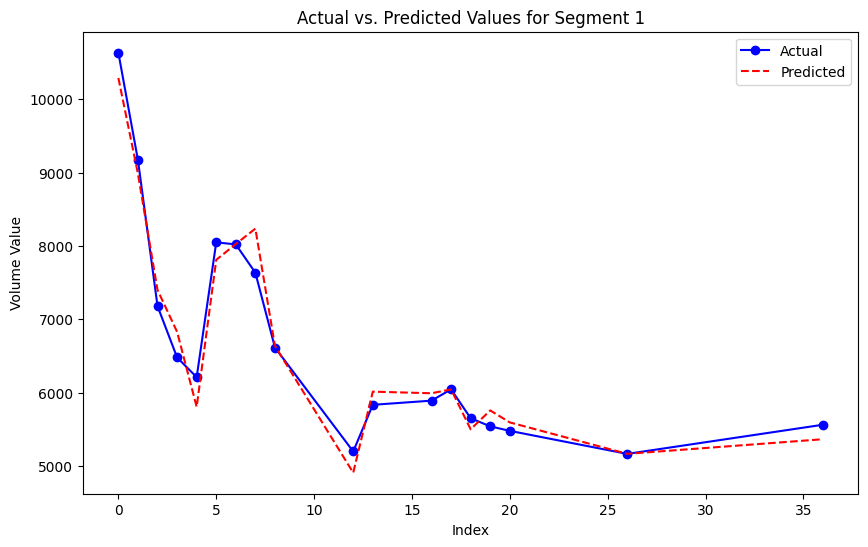

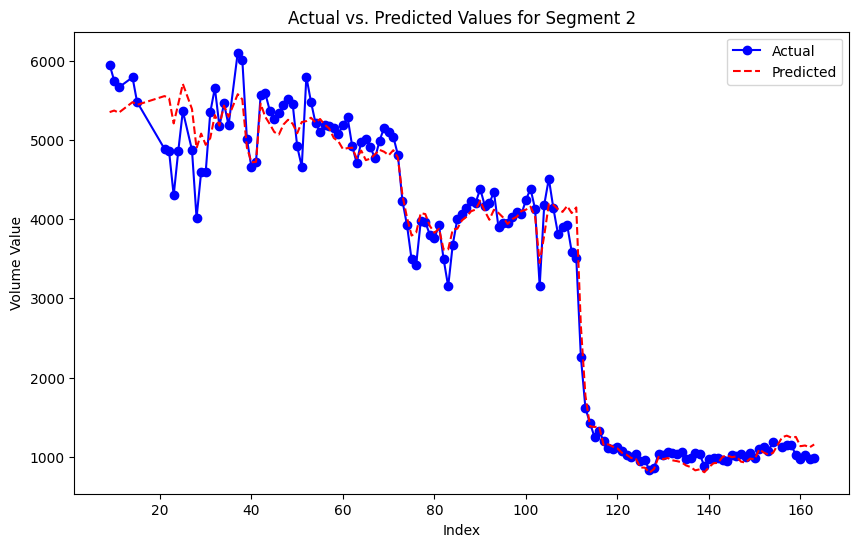

Segment: Segment_1
MAPE: 3.01%
Coefficients: [ 1.36739612e+04 -6.41193765e-11 -2.23426138e+03 -2.26639186e+03
  2.64023795e+03  1.90993887e-11  6.40333017e+02  1.13675220e+03
  9.46084695e+02 -3.55269879e+03  1.85987957e+03 -6.37333177e+03]
Intercept: 9973.82783949333

Segment: Segment_2
MAPE: 6.11%
Coefficients: [-6.34835084e+02 -2.27373675e-13 -1.93043521e+01  6.59639919e+01
  1.27291846e+03  6.25277607e-13  3.46309204e+01  1.55983345e+01
  9.05119762e+01  3.37654219e+01  5.85408685e+01  5.23837384e+01]
Intercept: 3640.516566498289



In [142]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import pwlf  # Piecewise Linear Fit
import matplotlib.pyplot as plt

# Sample DataFrame initialization (replace with actual data loading)
# df_new = pd.read_csv('your_data.csv')  # Load your dataset here

# Define columns to use in regression
columns_in_use = ['PPL', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect',
                  'D1', 'D1_cann', 'D1_Comp@Direct', 'D1_Comp@Indirect',
                  'Seasonality', 'Trend', 'Up_Down_Index', 'Cat_Pr_Index']

# Separate scaler for 'PPL' column to standardize it for segmentation and keep original values
ppl_scaler = StandardScaler()
df_new = df.copy()
df_new['PPL_scaled'] = ppl_scaler.fit_transform(df[['PPL']])  # Standardized PPL for segmentation

# Apply scaler only for regression features
scaler = StandardScaler()
df_new[columns_in_use] = scaler.fit_transform(df_new[columns_in_use])

# Use standardized 'PPL_scaled' values directly for pwlf segmentation
ppl_values = df_new['PPL_scaled'].values  # Standardized PPL values
volume_values = df_new['Volume'].values  # Replace with actual Volume variable

# Initialize the pwlf model
pwlf_model = pwlf.PiecewiseLinFit(ppl_values, volume_values)

# Determine the number of breakpoints (e.g., 3 segments, 2 breakpoints)
number_of_breakpoints = 2
breakpoints = pwlf_model.fit(number_of_breakpoints)

# Convert breakpoints back to original 'PPL' values for display
original_breakpoints = ppl_scaler.inverse_transform(np.array(breakpoints).reshape(-1, 1)).flatten()
print("Original breakpoints for PPL segmentation:", original_breakpoints)

# Segment results container
segment_results = {}

# Fit piecewise models for each segment based on standardized breakpoints
for i in range(len(breakpoints) - 1):
    # Segment data based on standardized 'PPL_scaled' breakpoints
    segment_df_new = df_new[(df_new['PPL_scaled'] >= breakpoints[i]) & (df_new['PPL_scaled'] < breakpoints[i + 1])]

    # Check if segment is empty
    if segment_df_new.empty:
        print(f"Segment {i+1} is empty. Skipping this segment.")
        continue

    # Define features (X) and Volume (y)
    X = segment_df_new[columns_in_use]
    y = segment_df_new['Volume']  # Replace with actual Volume column name

    # Initialize and train the linear regression model for each segment
    model = LinearRegression()
    model.fit(X, y)

    # Predict and calculate MAPE
    predictions = model.predict(X)
    mape = mean_absolute_percentage_error(y, predictions) * 100  # Convert to percentage

    # Store results
    segment_results[f'Segment_{i+1}'] = {
        'Model': model,
        'MAPE': mape,
        'Coefficients': model.coef_,
        'Intercept': model.intercept_,
        'Actual': y,
        'Predicted': predictions
    }

    # Plot actual vs. predicted values for this segment
    plt.figure(figsize=(10, 6))
    plt.plot(y.index, y, label='Actual', color='blue', marker='o')
    plt.plot(y.index, predictions, label='Predicted', color='red', linestyle='--')
    plt.title(f'Actual vs. Predicted Values for Segment {i+1}')
    plt.xlabel('Index')
    plt.ylabel('Volume Value')
    plt.legend()
    plt.show()

# Display the results in the console
for segment, result in segment_results.items():
    print(f"Segment: {segment}")
    print(f"MAPE: {result['MAPE'].round(2)}%")
    print(f"Coefficients: {result['Coefficients']}")
    print(f"Intercept: {result['Intercept']}\n")



[-1.62313516 -1.09484978  1.31731366]


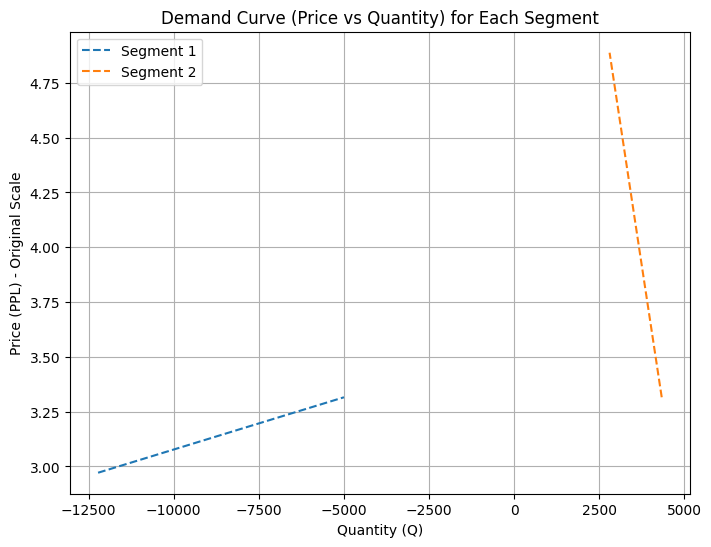

In [147]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the mean values of all columns except 'PPL' for the fixed part of the equation
mean_values = df_new[columns_in_use].mean()

# Range of standardized PPL values for plotting within each segment's range
ppl_ranges_standardized = []
for i in range(len(breakpoints) - 1):
    # Define a range of PPL values for each segment in standardized form
    ppl_range_std = np.linspace(breakpoints[i], breakpoints[i + 1], 100)  # Adjust 100 for finer control
    ppl_ranges_standardized.append(ppl_range_std)
print(breakpoints)
# Plot the demand curve for each segment with Q on x-axis and original PPL on y-axis
plt.figure(figsize=(8, 6))
for i, (segment, result) in enumerate(segment_results.items(), start=1):
    # Get coefficients and intercept for the segment
    intercept = result['Intercept']
    beta_price = result['Coefficients'][0]  # Assuming 'PPL' is the first coefficient
    other_coefficients = result['Coefficients'][1:]  # All other coefficients

    # Calculate the constant part of the equation from other columns' means
    fixed_part = np.dot(other_coefficients, mean_values[1:])

    # Calculate Q for the range of standardized PPL values in this segment
    Q_values = intercept + beta_price * ppl_ranges_standardized[i-1] + fixed_part

    # Convert standardized PPL values back to original scale for plotting on y-axis
    ppl_range_original = ppl_scaler.inverse_transform(ppl_ranges_standardized[i-1].reshape(-1, 1)).flatten()

    # Plot PPL (Price) on y-axis and Q (Quantity) on x-axis
    plt.plot(Q_values, ppl_range_original, label=f'Segment {i}', linestyle='--', marker='')

# Plot styling
plt.title("Demand Curve (Price vs Quantity) for Each Segment")
plt.xlabel("Quantity (Q)")
plt.ylabel("Price (PPL) - Original Scale")
plt.legend()
plt.grid()
plt.show()
